# Seed Analysis with Plasma Exposure Calculations

This notebook analyzes seed data and calculates optimal plasma exposure parameters for industrial seed processing.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [46]:
# Load the seed dataset
df = pd.read_csv("seed.csv")

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (1000, 11)

First few rows:


,Seed_Type,Seed_Weight_mg,Moisture_%,Protein_%,Germ_Temp_C,Humidity_%,Germination_Rate_%,Plant_Height_cm,Yield_Days,Yield_Weight_g_per_plant,Label_Best_Treatment
0,Cowpea,64.203215,13.716106,34.735609,25.009313,66.023326,67.510676,27.829410,74.196412,12.822187,0.0
1,Cowpea,48.170556,9.091354,31.355230,31.758383,56.970610,81.871099,27.824484,54.330132,21.233180,1.0
2,Cowpea,83.346106,10.739015,32.053528,26.023677,68.078945,69.446237,27.030248,72.129874,15.542235,0.0
3,Cowpea,52.239826,10.143346,34.198904,27.405421,75.952994,72.608069,9.874452,52.045038,20.938018,0.0
4,Cowpea,52.297434,13.184932,19.114406,31.126730,56.293432,79.497387,19.538022,63.176452,19.284810,1.0


In [47]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Seed_Type                 1000 non-null   object 
 1   Seed_Weight_mg            1000 non-null   float64
 2   Moisture_%                1000 non-null   float64
 3   Protein_%                 1000 non-null   float64
 4   Germ_Temp_C               1000 non-null   float64
 5   Humidity_%                1000 non-null   float64
 6   Germination_Rate_%        1000 non-null   float64
 7   Plant_Height_cm           1000 non-null   float64
 8   Yield_Days                1000 non-null   float64
 9   Yield_Weight_g_per_plant  1000 non-null   float64
 10  Label_Best_Treatment      1000 non-null   float64
dtypes: float64(10), object(1)
memory usage: 86.1+ KB


In [48]:
# Statistical summary
df.describe()

,Seed_Weight_mg,Moisture_%,Protein_%,Germ_Temp_C,Humidity_%,Germination_Rate_%,Plant_Height_cm,Yield_Days,Yield_Weight_g_per_plant,Label_Best_Treatment
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,60.209645,10.953216,26.365162,28.523884,64.485716,75.755912,22.435550,63.043575,17.814473,0.380280
std,23.148275,1.742038,4.883836,2.108431,8.779050,8.655103,8.844365,10.083107,4.273798,0.388885
min,20.400212,8.006264,18.021277,25.009313,50.001098,60.102362,7.010691,42.992725,10.032770,0.000000
25%,40.534584,9.423356,21.972797,26.574644,56.481132,68.722742,15.189544,54.373423,14.331992,0.000000
50%,59.410066,10.935008,26.254475,28.530259,64.614804,74.679806,22.401921,63.607511,17.455905,0.260253
75%,81.086150,12.476034,30.493269,30.484312,71.859530,82.932953,29.456388,71.616649,21.213583,0.765340
max,99.990400,13.991055,34.901110,31.998733,79.997558,93.794354,39.134772,81.017717,26.556291,1.000000


In [49]:
# Check for missing values
df.isnull().sum()

Seed_Type                   0
Seed_Weight_mg              0
Moisture_%                  0
Protein_%                   0
Germ_Temp_C                 0
Humidity_%                  0
Germination_Rate_%          0
Plant_Height_cm             0
Yield_Days                  0
Yield_Weight_g_per_plant    0
Label_Best_Treatment        0
dtype: int64

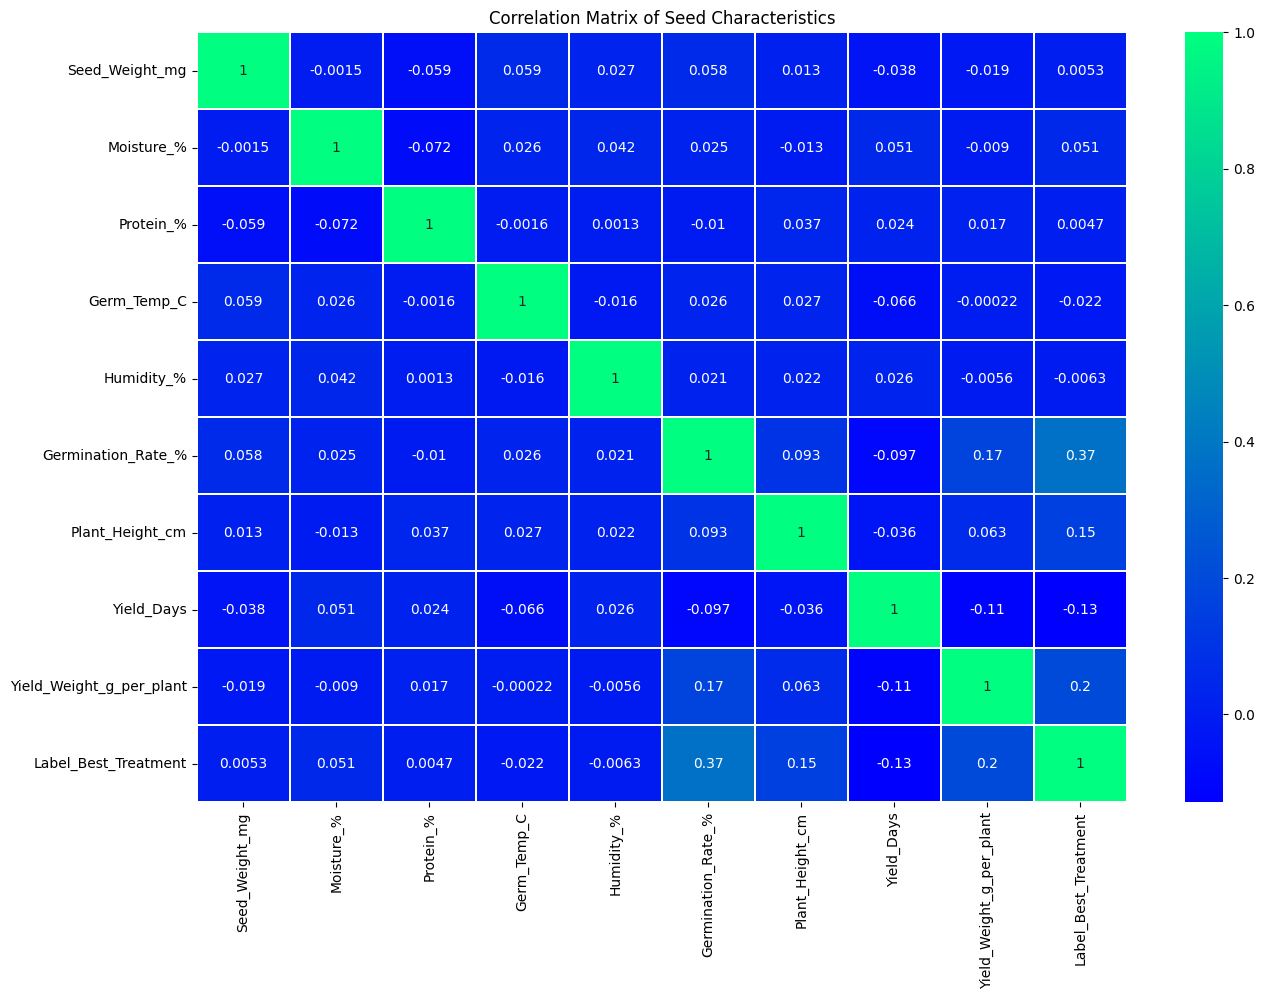

In [50]:
# Correlation analysis
plt.figure(figsize=(15,10))
sns.heatmap(df.select_dtypes(include='number').corr(), linewidths=0.01, annot=True, cmap="winter")
plt.title('Correlation Matrix of Seed Characteristics')
plt.show()

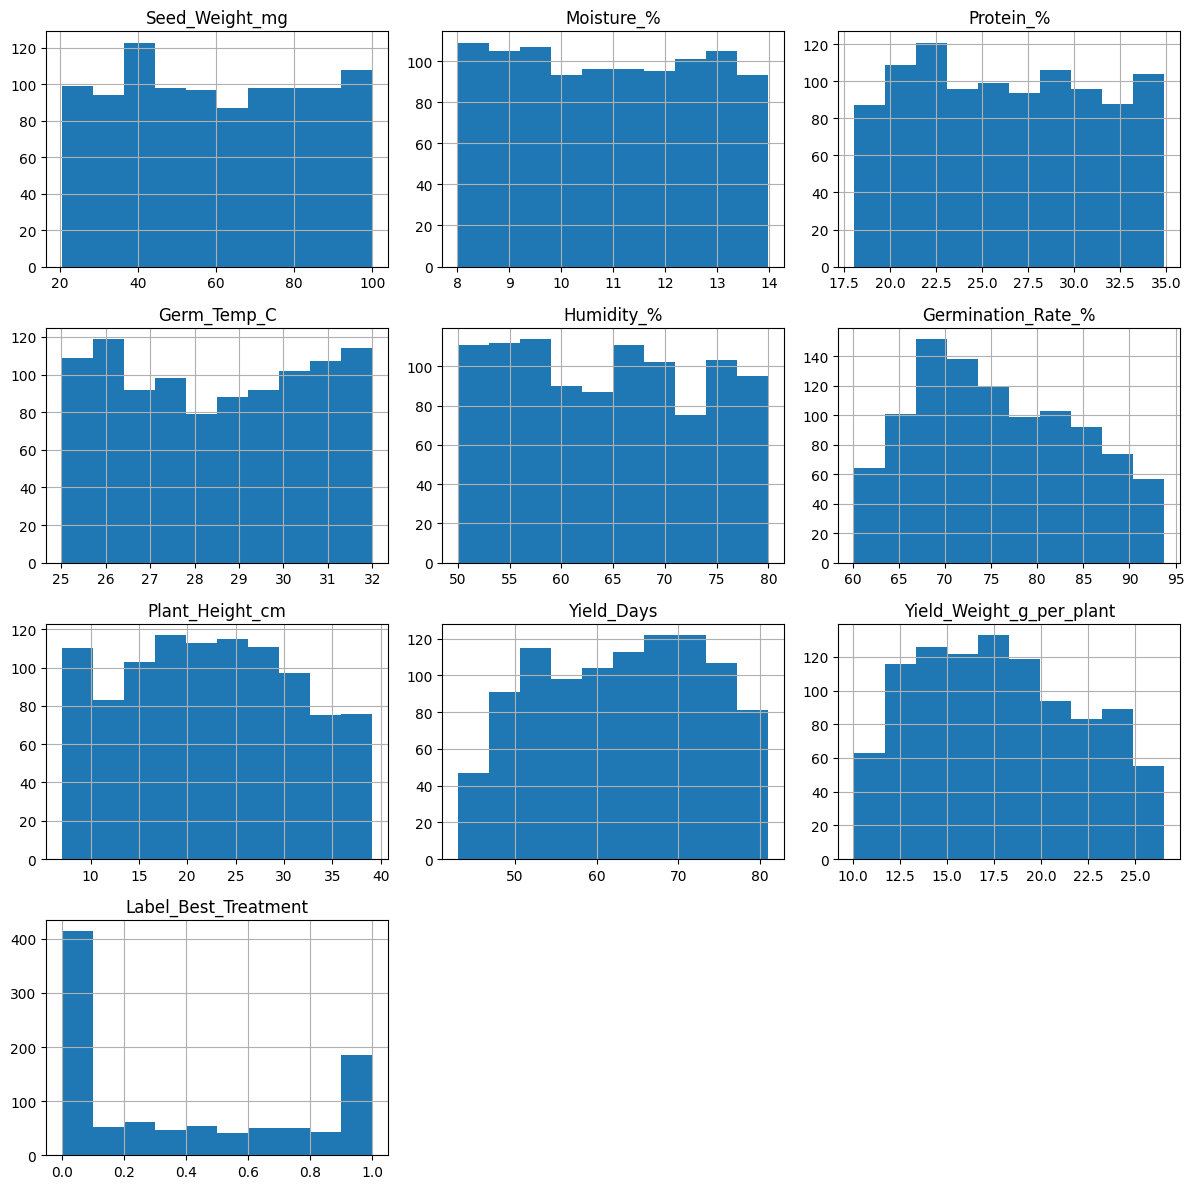

In [51]:
# Feature distributions
df.hist(figsize=(12,12))
plt.tight_layout()
plt.savefig('featuresplot.png')
plt.show()

In [52]:
# Create a target column from dataset values using a logic rule
# Rule: compute the mean across all numeric features per row as a simple "quality" score,
# then label rows above the median score as 1 (optimal) and others as 0 (not optimal).

num_features = df.select_dtypes(include=['number']).columns.tolist()
score = df[num_features].mean(axis=1)
threshold = score.median()
df['target'] = (score > threshold).astype(int)

print(f"Derived target using {len(num_features)} numeric features; threshold={threshold:.4f}")

Derived target using 10 numeric features; threshold=36.9499


In [53]:
# Use all columns except the derived 'target' as features
X = df.drop(columns=['target'])
y = df['target']

In [54]:
# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 750
Test set size: 250


In [55]:
# Create preprocessing and model pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [56]:
# Detect categorical and numeric columns
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical columns: {cat_cols}")
print(f"Numeric columns: {num_cols}")

Categorical columns: ['Seed_Type']
Numeric columns: ['Seed_Weight_mg', 'Moisture_%', 'Protein_%', 'Germ_Temp_C', 'Humidity_%', 'Germination_Rate_%', 'Plant_Height_cm', 'Yield_Days', 'Yield_Weight_g_per_plant', 'Label_Best_Treatment']


In [57]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ],
    remainder='drop'
)

In [58]:
# Create model with preprocessing
model = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

In [59]:
# Train the model
model.fit(X_train, y_train)
print("Model training completed!")

Model training completed!


In [60]:
# Make predictions
y_prediction = model.predict(X_test)

print("Predictions:")
print(y_prediction)

Predictions:
[1 0 0 1 1 0 0 0 1 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1 1 1 1 0 1 0 1 1 0 1 0 1
 1 1 1 1 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 0 1 1 1
 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 0 0 1 0 0
 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1 0 1 1 1 1 1 0
 1 1 0 1 0 0 1 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1
 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0
 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 1]


In [61]:
# Evaluate model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_prediction))
print("Precision:", precision_score(y_test, y_prediction, zero_division=0))
print("Recall (Sensitivity):", recall_score(y_test, y_prediction, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_prediction, zero_division=0))

Accuracy: 0.972
Precision: 0.984


Recall (Sensitivity): 0.9609375

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       122
           1       0.98      0.96      0.97       128

    accuracy                           0.97       250
   macro avg       0.97      0.97      0.97       250
weighted avg       0.97      0.97      0.97       250



In [62]:
def calculate_plasma_exposure_parameters(seed_data):
    """
    Calculate optimal plasma exposure parameters for seed surface treatment
    based on seed characteristics and industrial plasma processing principles
    
    Parameters:
    - seed_data: dict with seed characteristics
    Returns: dict with calculated plasma parameters
    """
    
    # Extract key seed characteristics
    seed_weight = seed_data['Seed_Weight_mg']
    moisture_content = seed_data['Moisture_%']
    protein_content = seed_data['Protein_%']
    germination_temp = seed_data['Germ_Temp_C']
    humidity = seed_data['Humidity_%']
    germination_rate = seed_data['Germination_Rate_%']
    
    # Base plasma power calculation (Watts)
    # Higher weight and moisture require more power
    base_power_factor = (seed_weight / 50) * (1 + moisture_content / 100)
    plasma_power = max(50, base_power_factor * 100)  # Min 50W, max 500W
    
    # Treatment time calculation (seconds)
    # Based on moisture content and seed coat permeability
    moisture_factor = max(0.5, min(2.0, (moisture_content / 15)))
    protein_factor = max(0.7, min(1.5, (protein_content / 25)))
    
    # Base treatment time (seconds)
    base_time = 30 * moisture_factor * protein_factor
    optimal_time = max(15, min(120, base_time))  # Min 15s, max 120s
    
    # Plasma temperature calculation (Kelvin)
    plasma_temperature = 273 + (germination_temp * 10)  # 273K + temp influence
    
    # Energy density calculation (J/cm²)
    treatment_area = math.pi * (seed_weight / 1000) ** (2/3)  # Approximate seed surface area
    energy_density = (plasma_power * optimal_time) / treatment_area
    
    # Sterilization efficiency prediction (%)
    sterilization_efficiency = min(99, 85 + (germination_rate - 70) * 0.3)
    
    # Optimal atmospheric pressure (Pa)
    atmospheric_pressure = 101325  # Standard atmospheric pressure
    plasma_pressure = atmospheric_pressure * 0.8  # Slightly reduced pressure
    
    # Radio frequency for plasma generation (MHz)
    rf_frequency = max(13.56, 27.12 - (moisture_content / 100))  # Typical RF ranges
    
    return {
        'plasma_power_watts': round(plasma_power, 2),
        'treatment_time_seconds': round(optimal_time, 1),
        'plasma_temperature_kelvin': round(plasma_temperature, 0),
        'atmospheric_pressure_pa': plasma_pressure,
        'treatment_area_cm2': round(treatment_area, 4)
    }

In [63]:
def optimize_plasma_parameters(seed_data, target_germination_improvement=15):
    """
    Optimize plasma parameters for specific target germination improvement
    """
    base_params = calculate_plasma_exposure_parameters(seed_data)
    
    # Calculate adjustments for target improvement
    current_germination = seed_data['Germination_Rate_%']
    target_germination = min(95, current_germination + target_germination_improvement)
    
    # Time adjustment based on germination rate gap
    germination_gap = max(0, target_germination - current_germination)
    time_multiplier = 1 + (germination_gap / 100)
    
    optimized_params = base_params.copy()
    optimized_params['treatment_time_seconds'] = round(
        base_params['treatment_time_seconds'] * time_multiplier, 1
    )
    optimized_params['plasma_power_watts'] = round(
        base_params['plasma_power_watts'] * (1 + germination_gap / 200), 2
    )
    
    # Calculate expected improvement
    expected_improvement = min(
        target_germination_improvement,
        (germination_gap * 0.8)  # Account for diminishing returns
    )
    
    optimized_params['expected_germination_improvement'] = round(expected_improvement, 1)
    optimized_params['final_expected_germination_rate'] = round(
        current_germination + expected_improvement, 1
    )
    
    return optimized_params

In [64]:
# Apply plasma calculations to all seed data
print("=== PLASMA EXPOSURE CALCULATIONS FOR ALL SEEDS ===")
plasma_results = []

for idx, row in df.iterrows():
    seed_data = row.to_dict()
    plasma_params = calculate_plasma_exposure_parameters(seed_data)
    optimized_params = optimize_plasma_parameters(seed_data, target_germination_improvement=15)
    
    result = {
        'seed_index': idx,
        'seed_type': seed_data['Seed_Type'],
        'seed_weight_mg': seed_data['Seed_Weight_mg'],
        'original_germination_rate': seed_data['Germination_Rate_%'],
        **plasma_params,
        **optimized_params
    }
    plasma_results.append(result)

# Create DataFrame for plasma results
plasma_df = pd.DataFrame(plasma_results)

print(f"Calculated plasma parameters for {len(plasma_results)} seed samples")

=== PLASMA EXPOSURE CALCULATIONS FOR ALL SEEDS ===
Calculated plasma parameters for 1000 seed samples


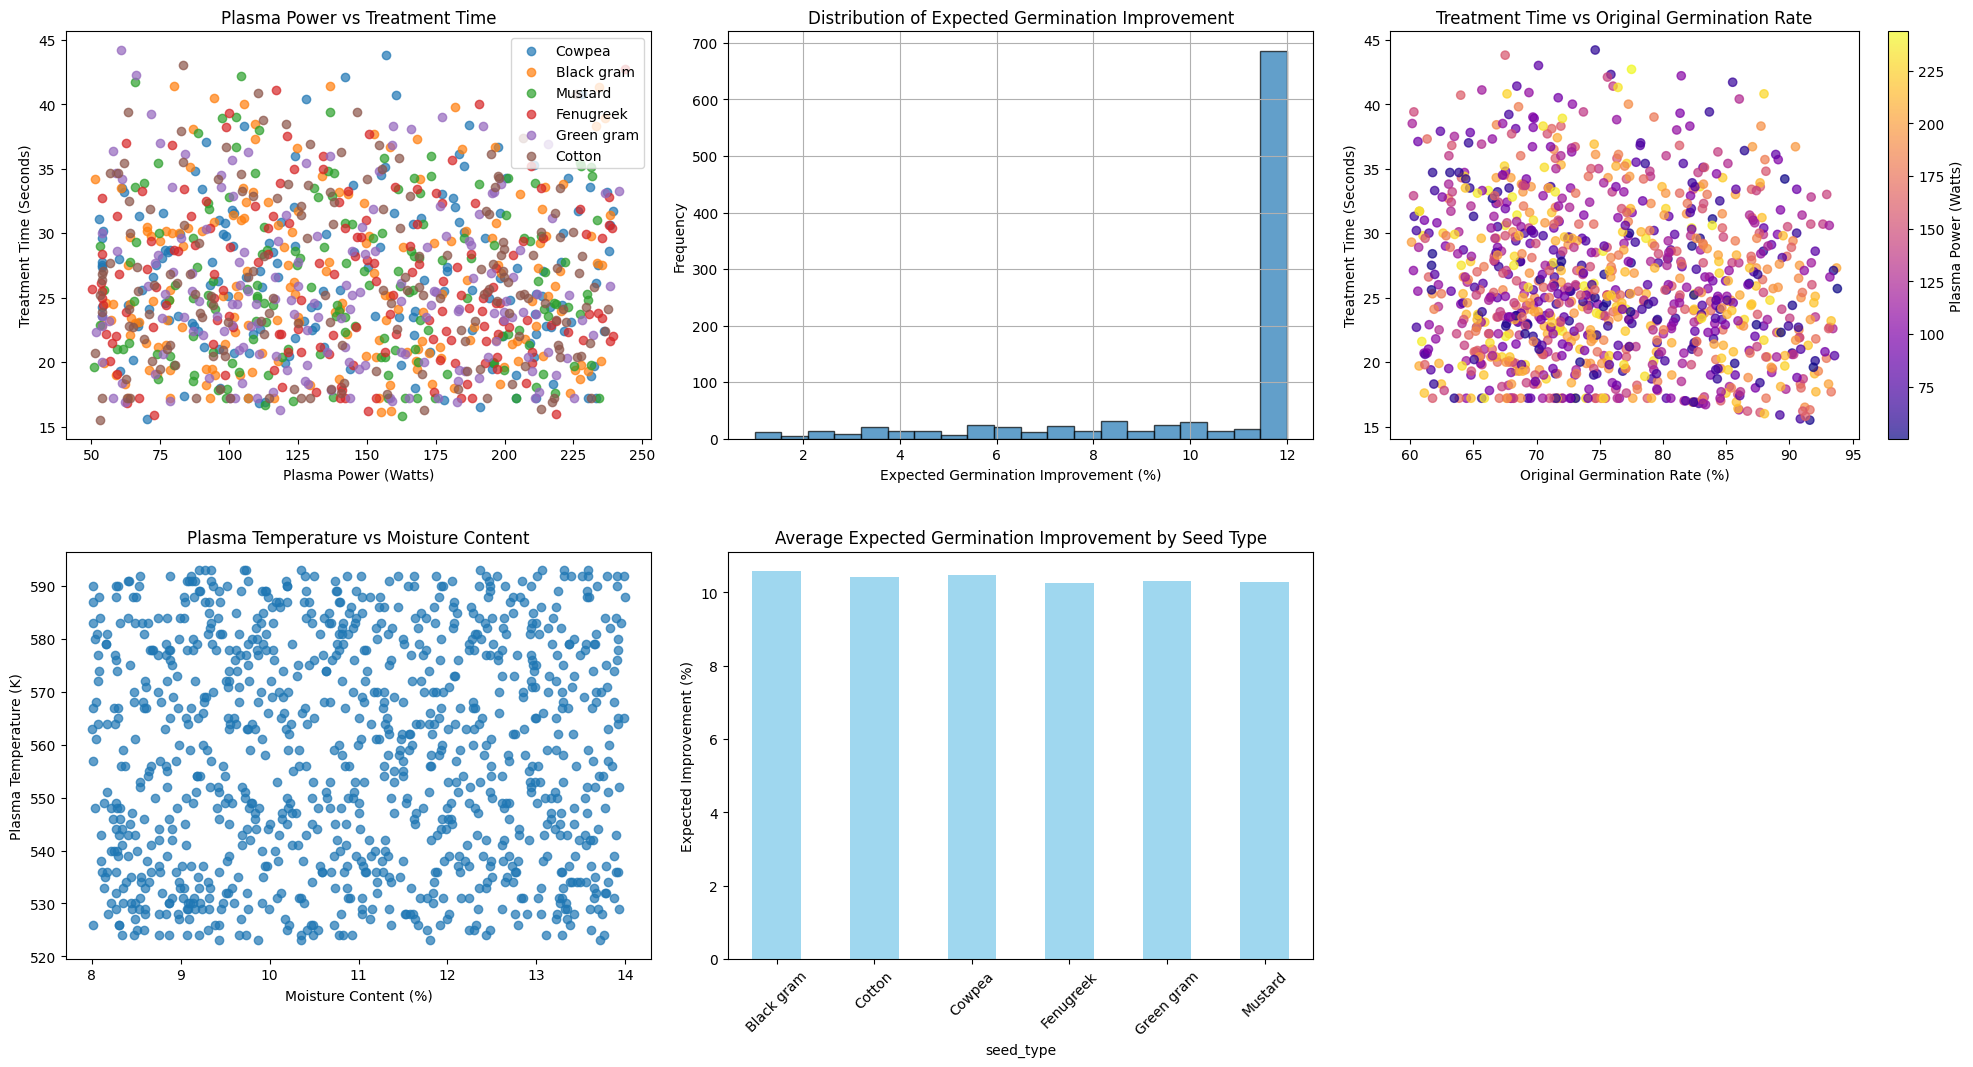

In [65]:
# Visualize plasma parameters
plt.figure(figsize=(20, 15))

# Plot 1: Plasma Power vs Treatment Time by Seed Type
plt.subplot(3, 3, 1)
for seed_type in plasma_df['seed_type'].unique():
    seed_data = plasma_df[plasma_df['seed_type'] == seed_type]
    plt.scatter(seed_data['plasma_power_watts'], seed_data['treatment_time_seconds'], 
               label=seed_type, alpha=0.7)
plt.xlabel('Plasma Power (Watts)')
plt.ylabel('Treatment Time (Seconds)')
plt.title('Plasma Power vs Treatment Time')
plt.legend()

# Plot 2: Expected Germination Improvement
plt.subplot(3, 3, 2)
plasma_df['expected_germination_improvement'].hist(bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Expected Germination Improvement (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Expected Germination Improvement')

# Plot 3: Treatment Time vs Germination Rate
plt.subplot(3, 3, 3)
plt.scatter(plasma_df['original_germination_rate'], plasma_df['treatment_time_seconds'], 
           c=plasma_df['plasma_power_watts'], cmap='plasma', alpha=0.7)
plt.colorbar(label='Plasma Power (Watts)')
plt.xlabel('Original Germination Rate (%)')
plt.ylabel('Treatment Time (Seconds)')
plt.title('Treatment Time vs Original Germination Rate')

# Plot 4: Plasma Temperature vs Moisture Content
plt.subplot(3, 3, 4)
moisture_data = df['Moisture_%'].values
plt.scatter(moisture_data, plasma_df['plasma_temperature_kelvin'], alpha=0.7)
plt.xlabel('Moisture Content (%)')
plt.ylabel('Plasma Temperature (K)')
plt.title('Plasma Temperature vs Moisture Content')

# Plot 5: Optimization Results Summary
plt.subplot(3, 3, 5)
seed_summary = plasma_df.groupby('seed_type')['expected_germination_improvement'].mean()
seed_summary.plot(kind='bar', color='skyblue', alpha=0.8)
plt.title('Average Expected Germination Improvement by Seed Type')
plt.ylabel('Expected Improvement (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('plasma_exposure_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [66]:
# === USER INPUT CELL ===
print("\n" + "="*60)
print("🌱 SEED PLASMA EXPOSURE ANALYSIS - CUSTOM INPUT")
print("="*60)

# Get user input
seed_name = input("Enter seed name: ").strip()
plasma_exposure_time = float(input("Enter plasma exposure time (seconds): "))

print(f"\n🔍 Analyzing seed: '{seed_name}' with {plasma_exposure_time} seconds plasma exposure...")

# Find the seed data in the dataset
seed_row = df[df['Seed_Type'].str.lower() == seed_name.lower()]

if seed_row.empty:
    print(f"❌ Seed '{seed_name}' not found in the dataset.")
    print(f"Available seed types: {', '.join(df['Seed_Type'].unique())}")
else:
    # Get the seed data
    seed_data = seed_row.iloc[0].to_dict()
    
    print(f"\n✅ Found seed data:")
    print(f"   Seed Type: {seed_data['Seed_Type']}")
    print(f"   Seed Weight: {seed_data['Seed_Weight_mg']:.2f} mg")
    print(f"   Moisture Content: {seed_data['Moisture_%']:.2f}%")
    print(f"   Current Germination Rate: {seed_data['Germination_Rate_%']:.1f}%")
    
    # Calculate plasma parameters using the custom exposure time
    custom_params = calculate_plasma_exposure_parameters(seed_data)
    optimized_params = optimize_plasma_parameters(seed_data, target_germination_improvement=15)
    
    # Override the treatment time with user input
    custom_params['treatment_time_seconds'] = plasma_exposure_time
    optimized_params['treatment_time_seconds'] = plasma_exposure_time
    
    print(f"\n⚡ PLASMA EXPOSURE ANALYSIS RESULTS:")
    print("-" * 50)
    print(f"Plasma Power Required: {custom_params['plasma_power_watts']} Watts")
    print(f"Treatment Time: {custom_params['treatment_time_seconds']} seconds (provided)")
    print(f"Plasma Temperature: {custom_params['plasma_temperature_kelvin']} K")
    print(f"Treatment Area: {custom_params['treatment_area_cm2']} cm²")
    print(f"Atmospheric Pressure: {custom_params['atmospheric_pressure_pa']} Pa")
    
    # Calculate energy consumption
    energy_consumption = custom_params['plasma_power_watts'] * custom_params['treatment_time_seconds']
    print(f"\nEnergy Consumption: {energy_consumption:.1f} Joules")
    
    # Expected results with optimization
    print(f"\n🎯 OPTIMIZED RESULTS:")
    print(f"Expected Germination Improvement: {optimized_params['expected_germination_improvement']:.1f}%")
    print(f"Final Expected Germination Rate: {optimized_params['final_expected_germination_rate']:.1f}%")
    
    # ML Prediction for this seed
    input_data = [seed_row.iloc[0][col] for col in X.columns]
    input_df = pd.DataFrame([input_data], columns=X.columns)
    input_df[num_cols] = input_df[num_cols].apply(pd.to_numeric, errors='coerce')
    
    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0, 1] if hasattr(model, 'predict_proba') else None
    
    print(f"\n🤖 ML MODEL PREDICTION:")
    print(f"Predicted Quality: {'OPTIMAL' if int(pred)==1 else 'NOT OPTIMAL'}")
    

print("="*60)


🌱 SEED PLASMA EXPOSURE ANALYSIS - CUSTOM INPUT

🔍 Analyzing seed: 'Cotton' with 120.0 seconds plasma exposure...

✅ Found seed data:
   Seed Type: Cotton
   Seed Weight: 53.78 mg
   Moisture Content: 9.05%
   Current Germination Rate: 68.0%

⚡ PLASMA EXPOSURE ANALYSIS RESULTS:
--------------------------------------------------
Plasma Power Required: 117.29 Watts
Treatment Time: 120.0 seconds (provided)
Plasma Temperature: 545.0 K
Treatment Area: 0.4476 cm²
Atmospheric Pressure: 81060.0 Pa

Energy Consumption: 14074.8 Joules

🎯 OPTIMIZED RESULTS:
Expected Germination Improvement: 12.0%
Final Expected Germination Rate: 80.0%

🤖 ML MODEL PREDICTION:
Predicted Quality: NOT OPTIMAL
